
# California Housing Dataset — Exploratory Data Analysis

## Project Goal

The goal of this project is to investigate the California Housing dataset and prepare it for machine learning regression models.  
The final objective is to predict the median house value of California districts using demographic, geographic, and housing-related features.

This notebook focuses on:

- Understanding the structure of the dataset
- Detecting anomalies and outliers
- Investigating feature distributions
- Understanding relationships between variables
- Identifying preprocessing requirements
- Building intuition before modeling

The notebook is intentionally exploratory and analytical rather than purely code-focused.



# 1. Dataset Loading and Initial Inspection

We begin by loading the dataset and understanding its structure.

The California Housing dataset is provided by `scikit-learn` and contains information about California census districts, including:
- income statistics,
- housing characteristics,
- geographic coordinates,
- and median house values.

Each row represents a district rather than an individual house.


In [2]:
from sklearn.datasets import fetch_california_housing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Getting the data
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [4]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [5]:
housing.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [6]:
print(type(housing.data))
print(housing.data.shape)
print(housing.data[:5])

<class 'numpy.ndarray'>
(20640, 8)
[[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 7.25740000e+00  5.20000000e+01  8.28813559e+00  1.07344633e+00
   4.96000000e+02  2.80225989e+00  3.78500000e+01 -1.22240000e+02]
 [ 5.64310000e+00  5.20000000e+01  5.81735160e+00  1.07305936e+00
   5.58000000e+02  2.54794521e+00  3.78500000e+01 -1.22250000e+02]
 [ 3.84620000e+00  5.20000000e+01  6.28185328e+00  1.08108108e+00
   5.65000000e+02  2.18146718e+00  3.78500000e+01 -1.22250000e+02]]


In [7]:
# Check the features
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [8]:
print(type(housing.target))
print(housing.target.shape)
print(housing.target[:5])

###---------------------###
### House Prices in units of $100000 ###
###---------------------###

<class 'numpy.ndarray'>
(20640,)
[4.526 3.585 3.521 3.413 3.422]


In [9]:
# Lets make a pandas DataFrame
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

# Add target column
df['MedHouseValue'] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [10]:
print(f'Shape: {df.shape}')
print(f'Columns:\n{df.columns}')
print(f'Data types:\n{df.dtypes}')

Shape: (20640, 9)
Columns:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseValue'],
      dtype='object')
Data types:
MedInc           float64
HouseAge         float64
AveRooms         float64
AveBedrms        float64
Population       float64
AveOccup         float64
Latitude         float64
Longitude        float64
MedHouseValue    float64
dtype: object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB



## Initial Observations

At this stage we can already identify several important characteristics of the dataset:

- The dataset contains only numerical features.
- No missing values are present.
- Features have significantly different scales.
- Some variables already appear potentially skewed or heavy-tailed.
- The target variable (`MedHouseValue`) is measured in units of $100,000.

Understanding these properties early is essential before training machine learning models.


In [12]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



# 2. Feature Distribution Analysis

Visualizing feature distributions provides a much clearer understanding of the data than summary statistics alone.

Histograms help reveal:
- skewed distributions,
- capped values,
- unusual concentrations,
- and potential outliers.

This step became one of the most informative parts of the analysis.


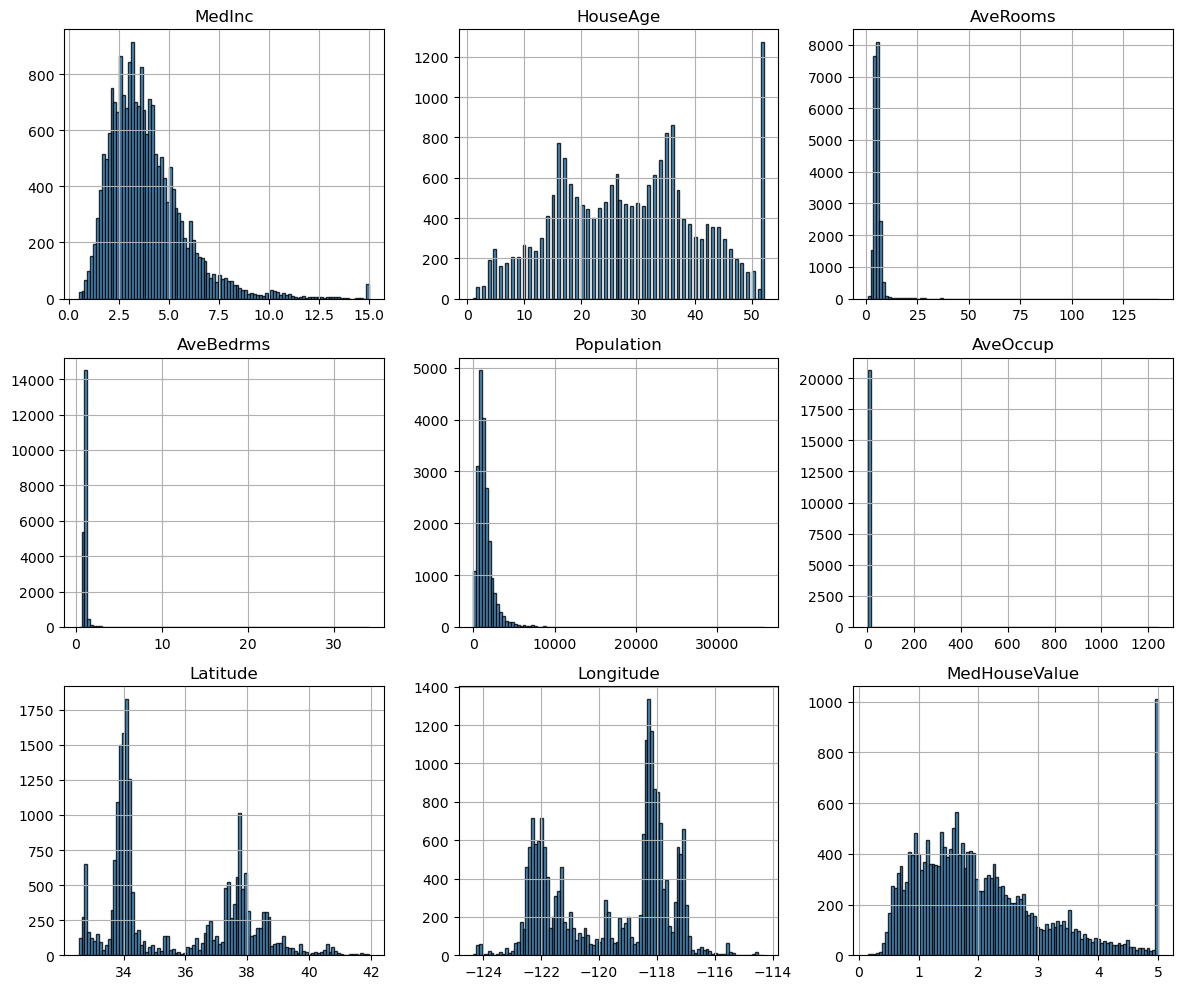

In [13]:
### ----------------------------------------- ###
### Histograms of every column in the dataset ###
### ----------------------------------------- ###

df.hist(figsize=(12, 10), bins=100, edgecolor='black', alpha=0.8)
#plt.title('Histogram of every column')
plt.tight_layout()
plt.show()


## Key Distribution Observations

### Median Income (`MedInc`)
The income distribution is positively skewed, with the majority of districts concentrated in low-to-middle income ranges and fewer high-income districts. This is economically realistic.

### House Age (`HouseAge`)
The distribution is relatively well spread across age ranges, although a visible concentration appears at the capped maximum value of 52 years. This suggests that the feature itself is truncated at an upper limit.

### Average Rooms / Bedrooms (`AveRooms`, `AveBedrms`)
Most districts exhibit realistic average values, although a small number of extreme observations exist. Since these values represent district-level averages rather than individual houses, extreme values may indicate either luxury regions or unstable household-based ratios.

### Population
Population is heavily right-skewed. Most districts contain moderate populations, while a small number of highly populated districts form the extreme tail of the distribution.

### Average Occupancy (`AveOccup`)
This feature contains the strongest visible outliers in the dataset. Earlier investigation revealed that some occupancy values are physically unrealistic and likely result from unstable denominator effects in household calculations.

### Latitude and Longitude
Initially underestimated during the first exploration phase, geographic coordinates later proved extremely important. The concentration of districts around specific coordinate ranges strongly suggests that location plays a major role in determining house value.

### Median House Value (`MedHouseValue`)
The target distribution exhibits clear censoring at the maximum recorded value of $500,000 (represented as 5.0 in the dataset), potentially limiting the model's ability to distinguish between expensive districts.



# 3. Outlier Investigation — Average Occupancy

The `AveOccup` feature required deeper investigation because of several extremely large values.

Instead of immediately removing outliers, the analysis first focused on understanding:
- whether the values were plausible,
- how frequent they were,
- and whether they represented meaningful rare cases or pathological observations.

This investigative approach is important in real-world data science workflows.


In [14]:
### --------------------- ###
'''We saw that the max in the AveOccup
is a really strange value indicating
maybe the exsistence of extreme outliers'''
### --------------------- ###

print(f'Count of rows with high average occupancy: {len(df[df["AveOccup"] > 100])}')
df[df['AveOccup'] > 100]

Count of rows with high average occupancy: 4


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
3364,5.5179,36.0,5.142857,1.142857,4198.0,599.714286,40.41,-120.51,0.675
13034,6.1359,52.0,8.275862,1.517241,6675.0,230.172414,38.69,-121.15,2.250
16669,4.2639,46.0,9.076923,1.307692,6532.0,502.461538,35.32,-120.70,3.500
19006,10.2264,45.0,3.166667,0.833333,7460.0,1243.333333,38.32,-121.98,1.375


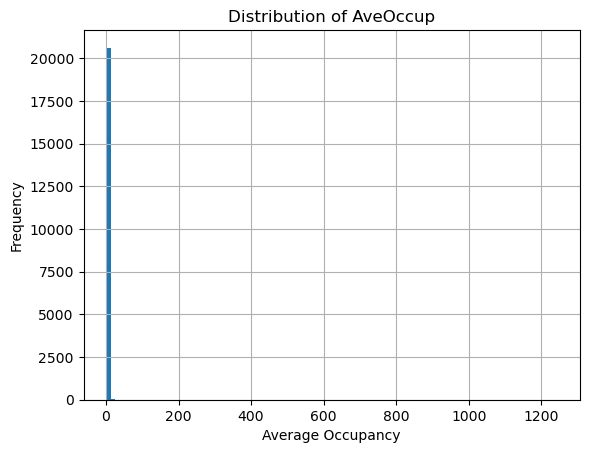

In [15]:
# Let's dive deeper in the AveOccup feature
df['AveOccup'].hist(bins=100)
plt.xlabel('Average Occupancy')
plt.ylabel('Frequency')
plt.title('Distribution of AveOccup')
plt.show()

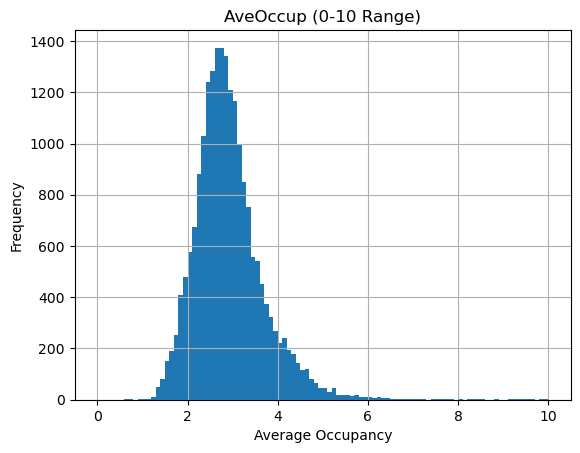

In [16]:
# Lets see the Average Occupancy without the outliers
df['AveOccup'].hist(bins=100, range=(0, 10))
plt.xlabel('Average Occupancy')
plt.ylabel('Frequency')
plt.title('AveOccup (0-10 Range)')
plt.show()

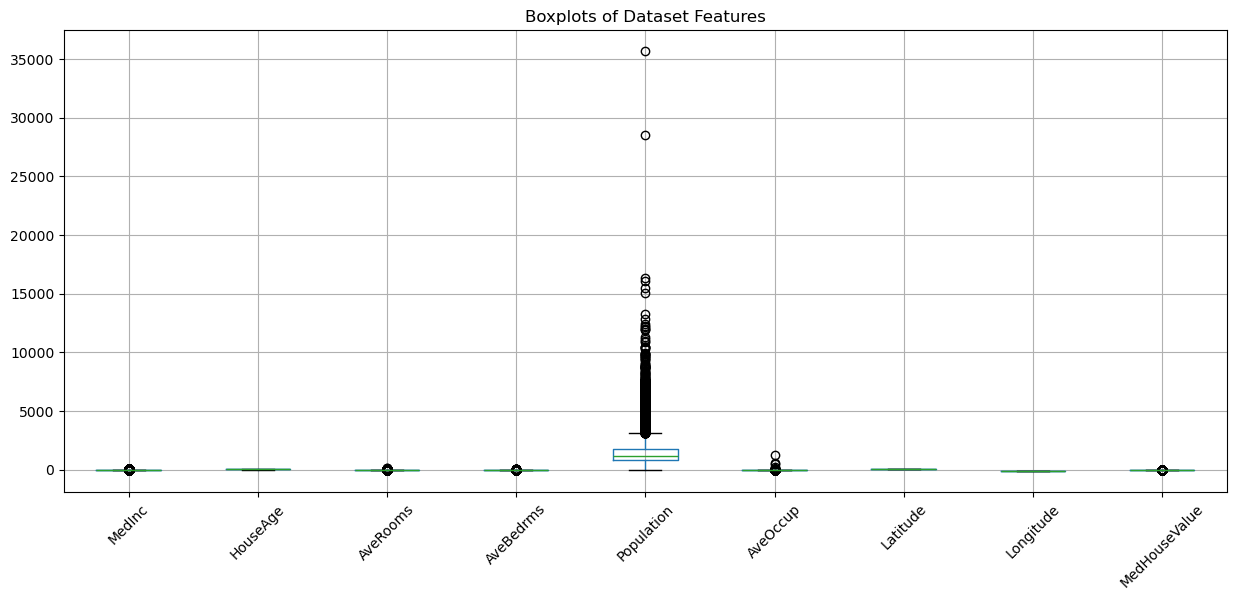

In [17]:
df.boxplot(figsize=(15, 6))
plt.xticks(rotation=45)
plt.title('Boxplots of Dataset Features')
plt.show()

In [18]:
###---------------------###
'''Let's check the features that indicate the
existence of outliers: Population and AveOccup.
To do this we will print the top 10 values.'''
###---------------------###
print(f"Top 10 Average Occupancy values:\n{df['AveOccup'].sort_values(ascending=False).head(10)}")
print(f"Top 10 Population values:\n{df['Population'].sort_values(ascending=False).head(10)}")

Top 10 Average Occupancy values:
19006    1243.333333
3364      599.714286
16669     502.461538
13034     230.172414
9172       83.171429
12104      63.750000
16420      51.400000
8874       41.214286
13366      33.952941
5986       21.333333
Name: AveOccup, dtype: float64
Top 10 Population values:
15360    35682.0
9880     28566.0
13139    16305.0
10309    16122.0
6057     15507.0
6066     15037.0
12215    13251.0
9019     12873.0
17413    12427.0
922      12203.0
Name: Population, dtype: float64


In [19]:
df[df["AveOccup"] > 50][
    ["Population", "AveOccup", "AveRooms", "MedInc", "MedHouseValue"]
]

,Population,AveOccup,AveRooms,MedInc,MedHouseValue
3364,4198.0,599.714286,5.142857,5.5179,0.675
9172,8733.0,83.171429,5.123810,4.2391,1.546
12104,1275.0,63.750000,7.600000,1.6250,1.625
13034,6675.0,230.172414,8.275862,6.1359,2.250
16420,1542.0,51.400000,5.366667,5.7485,1.625
16669,6532.0,502.461538,9.076923,4.2639,3.500
19006,7460.0,1243.333333,3.166667,10.2264,1.375


In [20]:
# Count rows with unusually high occupancy

print("AveOccup > 10 :", (df["AveOccup"] > 10).sum())
print("AveOccup > 20 :", (df["AveOccup"] > 20).sum())
print("AveOccup > 50 :", (df["AveOccup"] > 50).sum())
print("AveOccup > 100:", (df["AveOccup"] > 100).sum())

AveOccup > 10 : 37
AveOccup > 20 : 10
AveOccup > 50 : 7
AveOccup > 100: 4



# 4. Target Variable Investigation

The target variable (`MedHouseValue`) deserves special attention because target quality directly affects model performance.

The histogram below reveals one of the most important characteristics of the dataset:
a strong upper-value cap at 5.0 ($500,000).


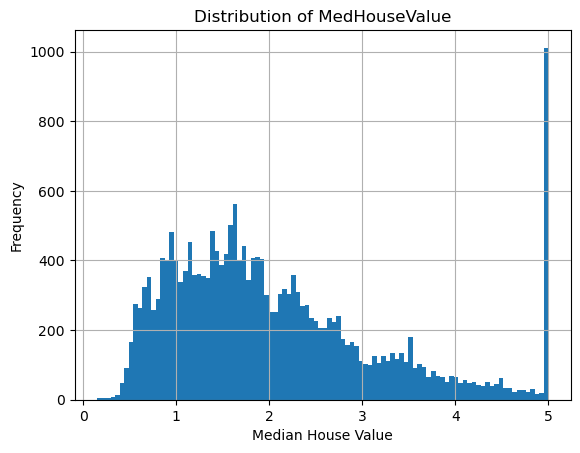

In [21]:
# Let's check the target value now.
df['MedHouseValue'].hist(bins=100)

plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.title('Distribution of MedHouseValue')
plt.show()

In [22]:
# We see that the target value is capped on the $500.000
(df['MedHouseValue'] >= 5).sum()

992

In [23]:
# Let's check some of the rows that this is happening
df[df['MedHouseValue'] >=5].head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
89,1.2434,52.0,2.929412,0.917647,396.0,4.658824,37.80,-122.27,5.00001
459,1.1696,52.0,2.436000,0.944000,1349.0,5.396000,37.87,-122.25,5.00001
493,7.8521,52.0,7.794393,1.051402,517.0,2.415888,37.86,-122.24,5.00001
494,9.3959,52.0,7.512097,0.955645,1366.0,2.754032,37.85,-122.24,5.00001
509,7.8772,52.0,8.282548,1.049861,947.0,2.623269,37.83,-122.23,5.00001
510,11.8603,39.0,7.911111,0.984127,808.0,2.565079,37.82,-122.22,5.00001
511,13.4990,42.0,8.928358,1.000000,1018.0,3.038806,37.82,-122.22,5.00001
512,12.2138,52.0,9.210227,1.039773,1001.0,2.843750,37.82,-122.23,5.00001
514,12.3804,52.0,9.122715,1.033943,1192.0,3.112272,37.82,-122.23,5.00001
517,8.7477,52.0,9.000000,1.134078,556.0,3.106145,37.82,-122.23,5.00001



# 5. Correlation and Feature Relationships

After understanding individual distributions and anomalies, the next step is to investigate relationships between variables.

The correlation analysis below helps identify:
- the strongest predictors,
- linear relationships,
- and potentially weak or misleading features.

As expected, `MedInc` emerges as the strongest individual predictor of house value, although no single feature alone fully explains the target.


In [24]:
# Correlation matrix
corr_matrix = df.corr()
corr_matrix['MedHouseValue'].sort_values(ascending=False)

MedHouseValue    1.000000
MedInc           0.688075
AveRooms         0.151948
HouseAge         0.105623
AveOccup        -0.023737
Population      -0.024650
Longitude       -0.045967
AveBedrms       -0.046701
Latitude        -0.144160
Name: MedHouseValue, dtype: float64

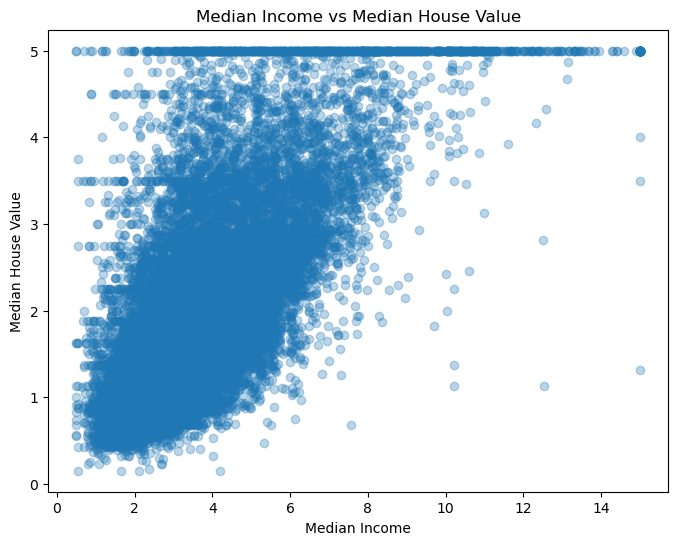

In [25]:
# Scatter plot: income vs house value

plt.figure(figsize=(8,6))

plt.scatter(
    df["MedInc"],
    df["MedHouseValue"],
    alpha=0.3
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")

plt.show()


# 6. Geographic Relationship with House Value

Housing prices are strongly influenced by geography.

To better understand the spatial structure of the dataset, we visualize districts using:
- Longitude on the x-axis
- Latitude on the y-axis
- Median house value as the color intensity

This visualization reveals geographic clustering of expensive and inexpensive districts across California.


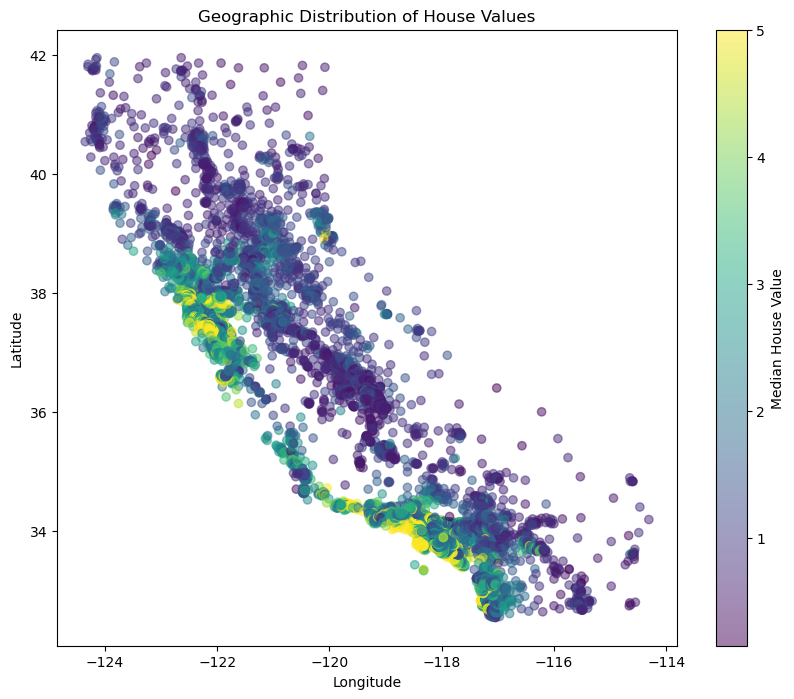

In [26]:

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseValue"],
    cmap="viridis",
    alpha=0.5
)

plt.colorbar(scatter, label="Median House Value")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of House Values")

plt.show()



# Final EDA Conclusions

The exploratory analysis revealed several important characteristics of the California Housing dataset:

- The dataset is generally clean and fully numerical.
- Several features exhibit strong skewness and extreme outliers.
- `AveOccup` contains a small number of unrealistic observations that justified preprocessing intervention.
- Both `HouseAge` and `MedHouseValue` contain capped maximum values.
- Geographic location appears highly influential in determining housing value.
- Median income is the strongest individual predictor, although house prices depend on multiple interacting factors.
- The dataset is suitable for regression modeling but requires careful preprocessing and interpretation.

These findings directly informed the preprocessing pipeline and the modeling strategy developed later in the project.
